In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("metrics.xlsx","Sheet1")
print(df)

    # threads  sorter dynamic -O3  distance dynamic -O3
0           1            0.150524              0.002572
1           1            0.154595              0.003066
2           1            0.160627              0.002052
3           2            0.079708              0.001758
4           2            0.087563              0.002273
5           2            0.080710              0.001753
6           4            0.068051              0.016953
7           4            0.057940              0.026980
8           4            0.060545              0.021180
9           6            0.055770              0.028372
10          6            0.055042              0.021486
11          6            0.067054              0.025172
12          8            0.070101              0.004161
13          8            0.063349              0.039402
14          8            0.081830              0.002020
15         10            0.064966              0.041076
16         10            0.095360              0

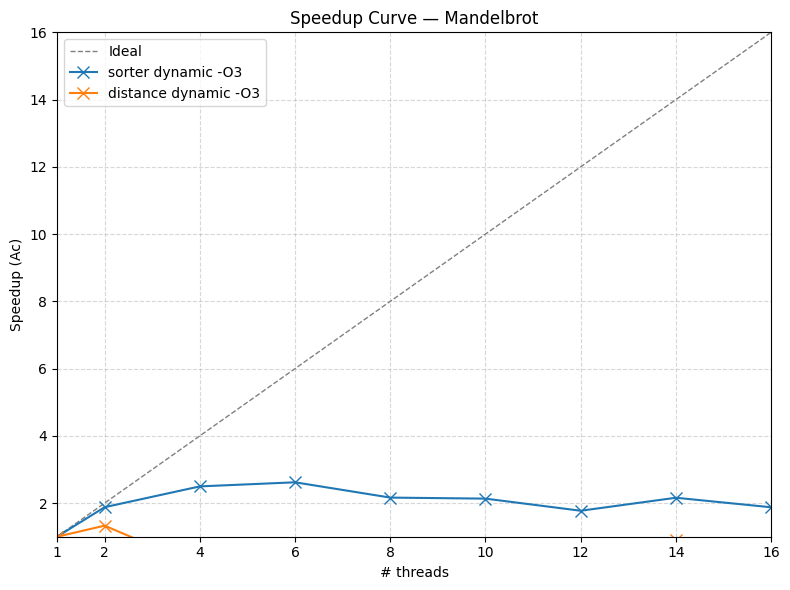

In [5]:
import matplotlib.pyplot as plt

# skip_threads = [40]

# Mean per thread count
means = df.groupby("# threads")[["sorter dynamic -O3", "distance dynamic -O3"]].mean().sort_index()
# means = means.drop(index=skip_threads, errors='ignore')

# Ts = T1 (mean execution time with 1 thread)
Ts = means.loc[1]

# Ac = Ts / Tp
ac = Ts / means

threads = means.index.tolist()
schedules = ["sorter dynamic -O3", "distance dynamic -O3"]
colors = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(8, 6))

# Ideal speedup line (1:1 reference)
ax.plot(threads, threads, linestyle='--', color='gray', linewidth=1, label='Ideal')

for sched, color in zip(schedules, colors):
    ax.plot(threads, ac[sched], marker='x', color=color, markersize=8, linewidth=1.5, label=sched)

ax.set_xlabel("# threads")
ax.set_ylabel("Speedup (Ac)")
ax.set_title("Speedup Curve — Mandelbrot")
ax.set_xticks(threads)
ax.set_xlim(1, threads[-1])
ax.set_ylim(1, threads[-1])
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


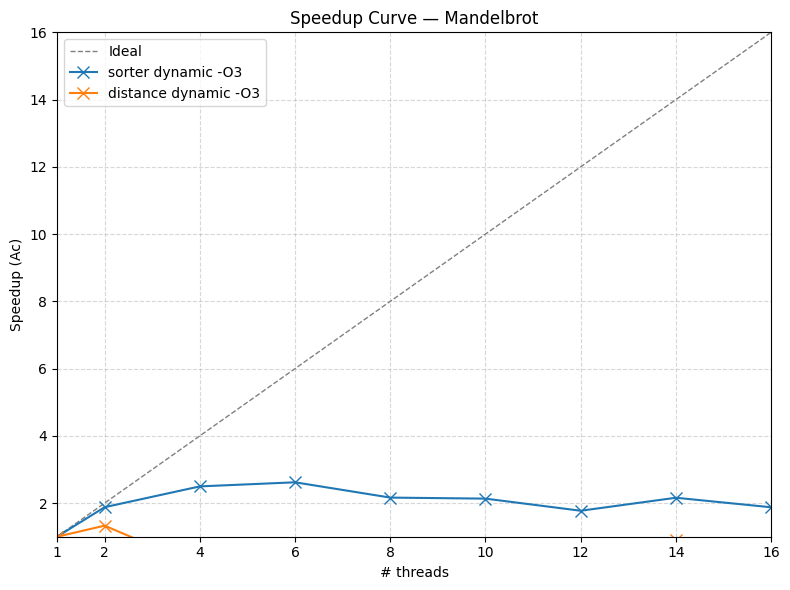

In [ ]:
import matplotlib.pyplot as plt

# Mean per thread count
means = df.groupby("# threads")[["distance dynamic -O3"]].mean().sort_index()

# Ts = T1 (mean execution time with 1 thread)
Ts = means.loc[1]

# Ac = Ts / Tp
ac = Ts / means

threads = means.index.tolist()
schedules = ["distance dynamic -O3"]
colors = ["tab:orange"]

fig, ax = plt.subplots(figsize=(8, 6))

# Ideal speedup line (1:1 reference)
ax.plot(threads, threads, linestyle='--', color='gray', linewidth=1, label='Ideal')

for sched, color in zip(schedules, colors):
    ax.plot(threads, ac[sched], marker='x', color=color, markersize=8, linewidth=1.5, label=sched)

ax.set_xlabel("# threads")
ax.set_ylabel("Speedup (Ac)")
ax.set_title("Speedup Curve — Mandelbrot")
ax.set_xticks(threads)
ax.set_xlim(1, threads[-1])
ax.set_ylim(1, threads[-1])
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
